In [1]:
import pandas as pd
import os 
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.tree import plot_tree
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.colors as mcolors

In [2]:
df = pd.read_csv('../banco_fenotipos_conformal.csv') # Load the phenotypic data
df = df.drop(columns=['id','samplefilename', 'CP1','CP2','CP3','CP4','CP5','CP6']) # remove the id from the table
colunas_categoricas = ['fumo', 'raca_cor', 'conjugal3', 'trabalho2', 'bebem2']
df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True, dtype=int) # Turns the categorical columns into 0 and 1
colunas_categoricas = [coluna for coluna in df.columns if df[coluna].nunique() < 6]

In [53]:
df.columns

Index(['hemoglobina_g_dl', 'glicose_mg_dl', 'sexo', 'idade', 'faixa_etaria',
       'imc', 'imc_categoria_4', 'imc_categoria', 'excesso_peso', 'obesidade',
       'circunferencia_cintura_cm', 'obesidade_central',
       'circ_cintura_estatura', 'circ_cintura_estatura_cat',
       'medicamento_dm_bioq', 'diabetes_tipo_2', 'homa_ir', 'homa_categoria',
       'pressao_sistolica_final', 'pressao_diastolica_final',
       'medicamento_has_bioq', 'hipertensao_tipo_2',
       'colesterol_nao_hdl_mg_dl', 'colesterol_nao_hdl_cat', 'fumo_fumante',
       'fumo_nunca', 'raca_cor_branca', 'raca_cor_indigena', 'raca_cor_outras',
       'raca_cor_parda', 'raca_cor_preta', 'estado_civil_casado_uniao_est',
       'estado_civil_separado_divorc', 'estado_civil_solteiro',
       'estado_civil_viuvo', 'trabalho_estudante', 'trabalho_nao_trabalha',
       'trabalho_trabalha', 'consumo_alcool_ns_nr',
       'consumo_alcool_ate_3x_semana', 'consumo_alcool_nao_bebe'],
      dtype='str')

In [3]:
nrespondeu = [coluna for coluna in df.columns if 'respondeu' in coluna]
df = df.drop(columns=nrespondeu)

In [4]:
df = df.rename(columns={
    'hb_g_dl': 'hemoglobina_g_dl',
    'glicose_mg_dl': 'glicose_mg_dl',
    'sexo': 'sexo',
    'idade': 'idade',
    'faixa_etaria': 'faixa_etaria',
    'imc': 'imc',
    'imc_cat4_aferido': 'imc_categoria_4',
    'imc_cat_aferido': 'imc_categoria',
    'ep': 'excesso_peso',
    'obesidade': 'obesidade',
    'ccm': 'circunferencia_cintura_cm',
    'obes_central': 'obesidade_central',
    'cc_estat': 'circ_cintura_estatura',
    'cc_estat_cat': 'circ_cintura_estatura_cat',
    'medDM_bioq': 'medicamento_dm_bioq',
    'diabetes2': 'diabetes_tipo_2',
    'HOMA_IR': 'homa_ir',
    'HOMA_cat': 'homa_categoria',
    'pas_final': 'pressao_sistolica_final',
    'pad_final': 'pressao_diastolica_final',
    'medHAS_bioq': 'medicamento_has_bioq',
    'has2': 'hipertensao_tipo_2',
    'col_nao_hdlc_mg_dl': 'colesterol_nao_hdl_mg_dl',
    'colnaohdl_cat': 'colesterol_nao_hdl_cat',
    'fumo_fumante': 'fumo_fumante',
    'fumo_nunca': 'fumo_nunca',
    'raca_cor_branca': 'raca_cor_branca',
    'raca_cor_indígena': 'raca_cor_indigena',
    'raca_cor_outras': 'raca_cor_outras',
    'raca_cor_parda': 'raca_cor_parda',
    'raca_cor_preta': 'raca_cor_preta',
    'conjugal3_casado/un. estavel': 'estado_civil_casado_uniao_est',
    'conjugal3_separado/desq/divorc': 'estado_civil_separado_divorc',
    'conjugal3_solteiro': 'estado_civil_solteiro',
    'conjugal3_viuvo': 'estado_civil_viuvo',
    'trabalho2_estudante': 'trabalho_estudante',
    'trabalho2_nÃ£o trabalha': 'trabalho_nao_trabalha',
    'trabalho2_trabalha': 'trabalho_trabalha',
    'bebem2_NS/NR': 'consumo_alcool_ns_nr',
    'bebem2_atÃ© 3x semana': 'consumo_alcool_ate_3x_semana',
    'bebem2_nÃ£o bebe': 'consumo_alcool_nao_bebe'
})

In [13]:
def extrair_frequencia_estabilidade_grafo(
    df, alvos, num_trees=500, iteracoes=50, fracao_amostra=0.5, q=3
):
    """Extrai a frequência de estabilidade das arestas baseado no artigo

    Fellinghauer et al. (2013).

    Parâmetros:
    - q: Número de top variáveis com maior importância que serão selecionadas
         em cada iteração (frequência binária).
    """
    # Matriz inicializada com zeros
    matriz_estabilidade = pd.DataFrame(
        index=alvos, columns=df.columns, dtype=np.float64
    ).fillna(0.0)

    for target in alvos:
        print(f"Rodando a variável {target}")
        df_alvo = df.dropna(subset=[target])

        for i in range(iteracoes):
            if fracao_amostra > 1:
                df_sub = df_alvo.sample(n=fracao_amostra, random_state=i)
            else:pu
                df_sub = df_alvo.sample(frac=fracao_amostra, random_state=i)
            

            X = df_sub.drop(columns=[target])
            y = df_sub[target]

            if target not in colunas_categoricas:
                modelorf = RandomForestRegressor(
                    n_estimators=num_trees,
                    max_features=0.3,
                    n_jobs = -1,
                    bootstrap=False,
                )
            else:
                modelorf = RandomForestClassifier(
                    n_estimators=num_trees,
                    max_features=0.3,
                    class_weight='balanced',
                    bootstrap=False, # Bootstrap ligado e 1 iteracao, e 100% dos dados
                    n_jobs = -1,
                )

            modelorf.fit(X, y)

            resultado_permutacao = permutation_importance(
                modelorf, X, y, n_repeats=3, random_state=i, n_jobs=-1
            )
            importancias = resultado_permutacao.importances_mean

            importancias_series = pd.Series(importancias, index=X.columns)

            top_q_variaveis = importancias_series.nlargest(q).index

            matriz_estabilidade.loc[target, top_q_variaveis] += 1.0

        matriz_estabilidade.loc[target] = (
            matriz_estabilidade.loc[target] / iteracoes
        )

    return matriz_estabilidade

In [14]:
%%time
# --- CÁLCULO DO LIMIAR DO ARTIGO ---
p = len(df.columns)  # Número total de variáveis no seu dataset
P = (p * (p - 1)) / 2  # Total de arestas possíveis em um grafo NÃO-DIRECIONADO
EV = 1 # Número esperado de falsos positivos que você tolera no grafo todo


IMPORT_MIN = 0.75

q= int(np.sqrt((2*IMPORT_MIN -1) * EV * P))
print(q)
matriz_import = extrair_frequencia_estabilidade_grafo(df, df.columns, 100, 20,100,q)


20
Rodando a variável hemoglobina_g_dl
Rodando a variável glicose_mg_dl
Rodando a variável sexo
Rodando a variável idade
Rodando a variável faixa_etaria
Rodando a variável imc
Rodando a variável imc_categoria_4
Rodando a variável imc_categoria
Rodando a variável excesso_peso
Rodando a variável obesidade
Rodando a variável circunferencia_cintura_cm
Rodando a variável obesidade_central
Rodando a variável circ_cintura_estatura
Rodando a variável circ_cintura_estatura_cat
Rodando a variável medicamento_dm_bioq
Rodando a variável diabetes_tipo_2
Rodando a variável homa_ir
Rodando a variável homa_categoria
Rodando a variável pressao_sistolica_final
Rodando a variável pressao_diastolica_final
Rodando a variável medicamento_has_bioq
Rodando a variável hipertensao_tipo_2
Rodando a variável colesterol_nao_hdl_mg_dl
Rodando a variável colesterol_nao_hdl_cat
Rodando a variável fumo_fumante
Rodando a variável fumo_nunca
Rodando a variável raca_cor_branca
Rodando a variável raca_cor_indigena
Rodando

In [23]:
matriz_numpy = matriz_import.to_numpy()

matriz_min = np.minimum(matriz_numpy,matriz_numpy.T)

matriz_final = pd.DataFrame(
    matriz_min, index=matriz_import.index, columns=matriz_import.columns
)

In [38]:
matriz_final
df_binario = matriz_final.copy()
df_binario = np.where(df_binario < IMPORT_MIN, 0, 1)
adj_matrix = pd.DataFrame(df_binario, index = matriz_final.index, columns= matriz_final.columns)

In [39]:
matriz_final

,hemoglobina_g_dl,glicose_mg_dl,sexo,idade,faixa_etaria,imc,imc_categoria_4,imc_categoria,excesso_peso,obesidade,...,estado_civil_casado_uniao_est,estado_civil_separado_divorc,estado_civil_solteiro,estado_civil_viuvo,trabalho_estudante,trabalho_nao_trabalha,trabalho_trabalha,consumo_alcool_ns_nr,consumo_alcool_ate_3x_semana,consumo_alcool_nao_bebe
hemoglobina_g_dl,0.00,1.00,1.00,1.00,0.30,1.00,0.95,0.50,0.25,0.10,...,0.30,0.55,0.20,0.40,0.05,0.35,0.70,0.10,0.65,0.40
glicose_mg_dl,1.00,0.00,0.60,0.95,0.85,1.00,0.80,0.20,0.00,0.10,...,0.25,0.10,0.50,0.10,0.05,0.25,0.15,0.00,0.10,0.05
sexo,1.00,0.60,0.00,0.20,1.00,0.20,0.10,0.20,0.05,1.00,...,0.05,0.00,0.00,0.10,0.00,0.00,0.00,0.00,0.00,0.00
idade,1.00,0.95,0.20,0.00,1.00,1.00,1.00,0.10,0.05,0.00,...,0.35,0.05,1.00,0.35,0.85,1.00,1.00,0.05,0.20,0.15
faixa_etaria,0.30,0.85,1.00,1.00,0.00,0.55,1.00,0.95,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
imc,1.00,1.00,0.20,1.00,0.55,0.00,1.00,1.00,1.00,1.00,...,0.25,0.55,0.05,0.10,0.00,0.35,0.35,0.10,0.20,0.30
imc_categoria_4,0.95,0.80,0.10,1.00,1.00,1.00,0.00,1.00,1.00,1.00,...,0.50,0.20,0.10,0.10,0.00,0.65,0.75,0.10,0.10,0.05
imc_categoria,0.50,0.20,0.20,0.10,0.95,1.00,1.00,0.00,1.00,1.00,...,0.05,0.00,0.15,0.00,0.05,0.05,0.00,0.00,0.10,0.10
excesso_peso,0.25,0.00,0.05,0.05,1.00,1.00,1.00,1.00,0.00,1.00,...,0.00,0.00,0.10,0.00,0.05,0.00,0.00,0.00,0.05,0.05
obesidade,0.10,0.10,1.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


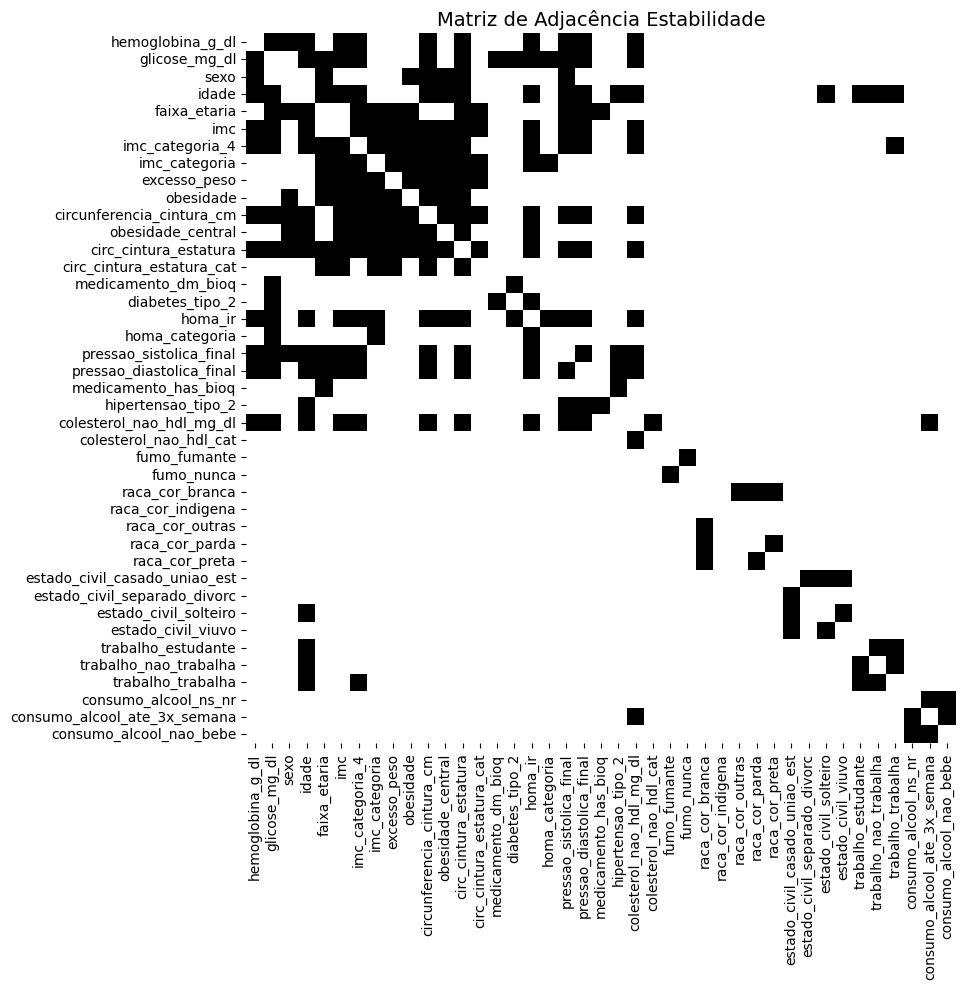

In [56]:
# 1. Cria uma tela maior para legibilidade
plt.figure(figsize=(12, 10))

# 2. Define uma paleta customizada: 0 = Branco, 1 = Preto
# O Seaborn interpola entre essas cores, então o resultado será binário
paleta_custom = mcolors.LinearSegmentedColormap.from_list("", ["white", "black"])

# 3. Gera o heatmap com as configurações corretas
sns.heatmap(
    adj_matrix,
    annot=False,          # Mantém os números visíveis
    cmap=paleta_custom,  # Aplica a paleta personalizada
    cbar=False,          # Remove a barra lateral de cores
    square=True,         # Força células quadradas
    fmt='g',             # Formata números como inteiros simples
    annot_kws={"size": 8} # Ajusta o tamanho da fonte das anotações se necessário
)

# 4. Adiciona o título e formatação final
plt.title("Matriz de Adjacência Estabilidade", fontsize=14)
plt.tight_layout() # Ajusta automaticamente para não cortar os nomes das variáveis
plt.savefig('Teste.png')
plt.show()

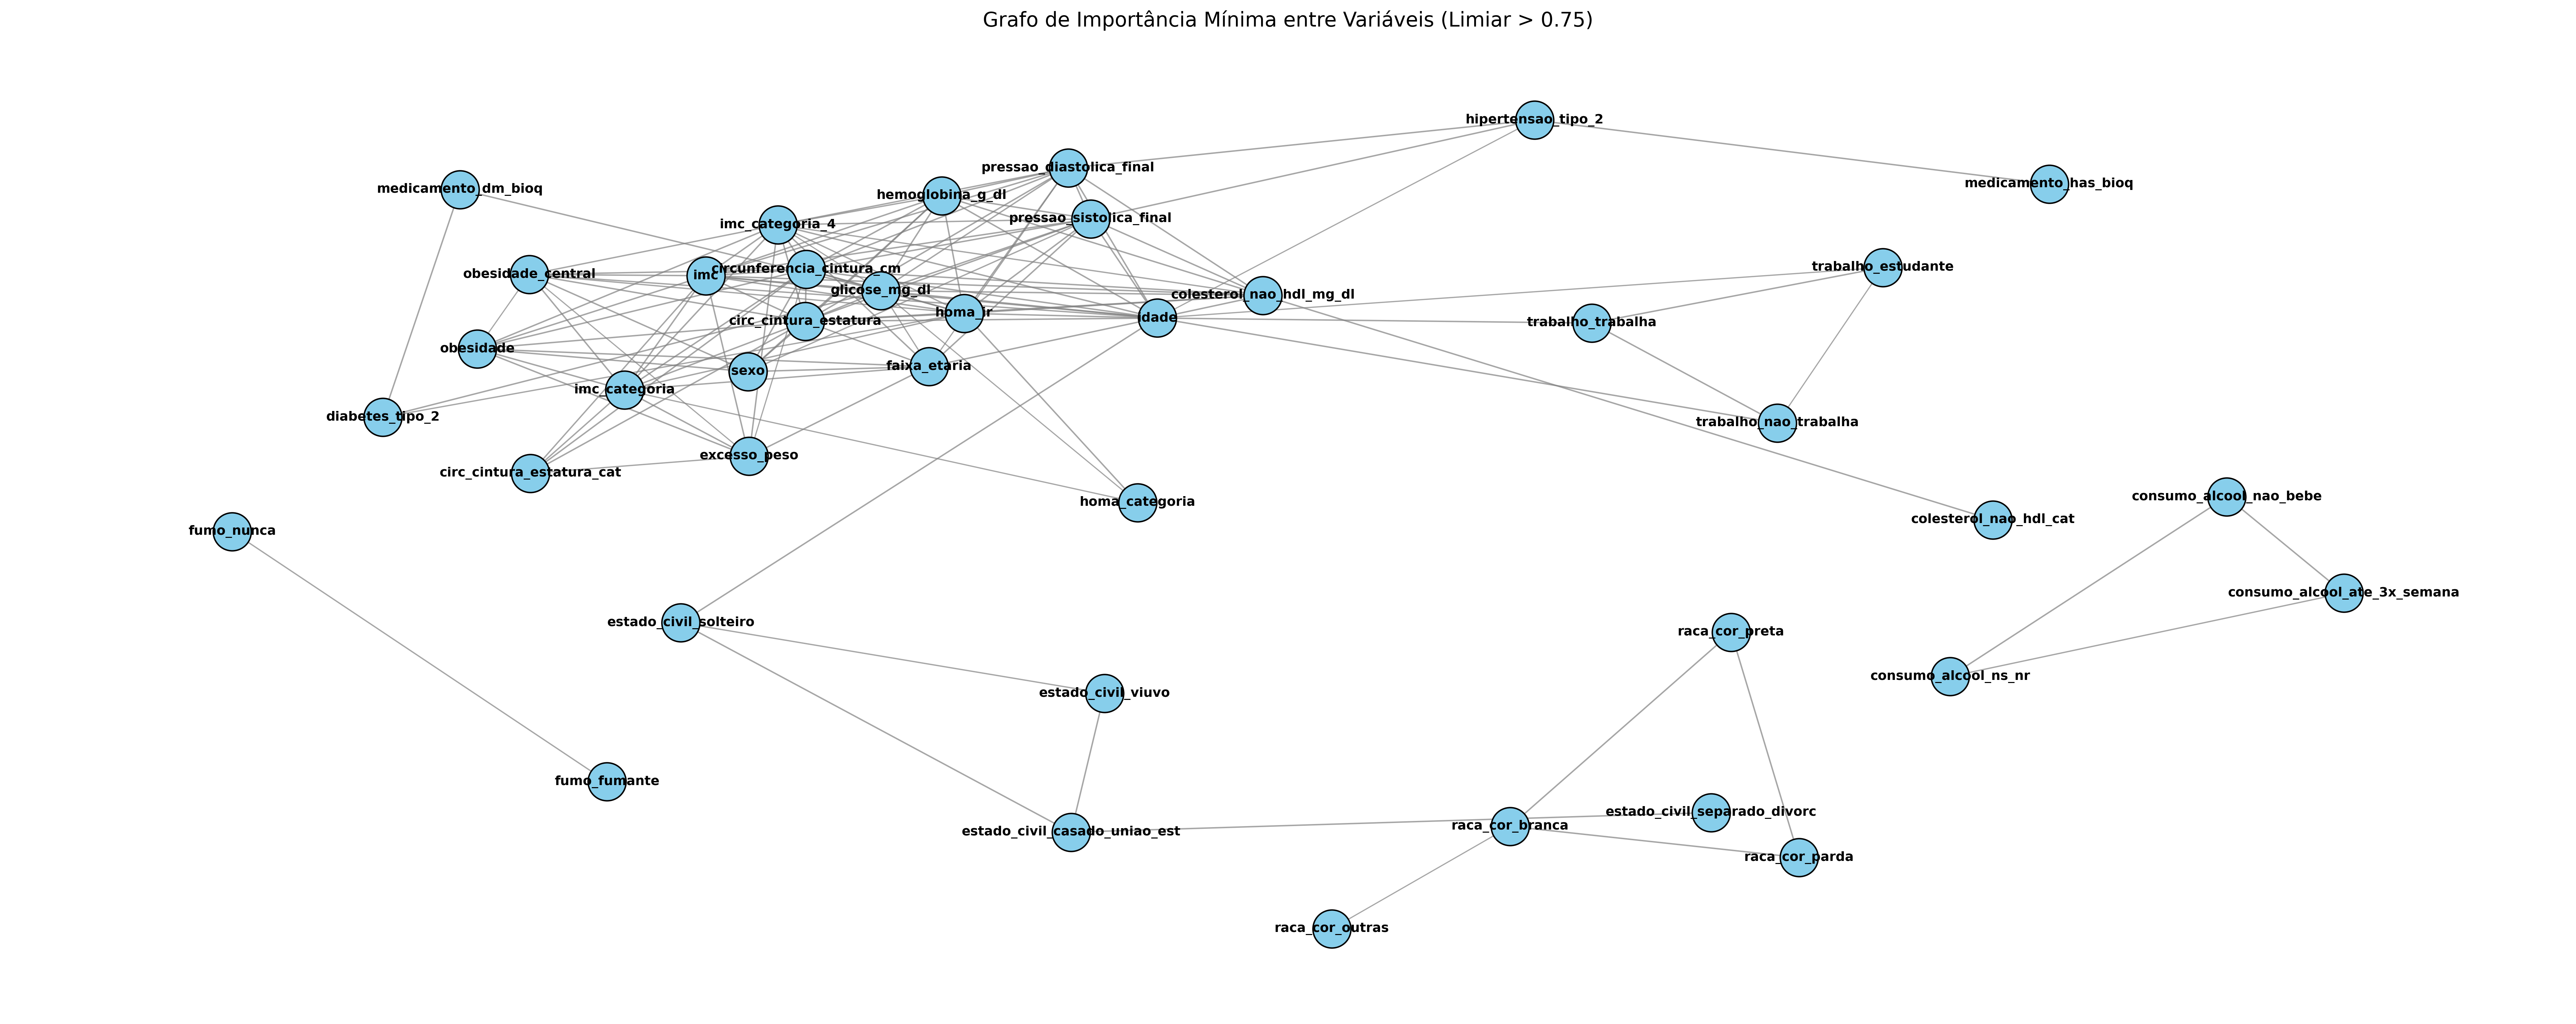

In [41]:
Grafo = nx.from_pandas_adjacency(matriz_final, create_using=nx.Graph)

arestas_para_remover = [
    (u, v)
    for u, v, d in Grafo.edges(data=True)
    if d["weight"] <= IMPORT_MIN
]
Grafo.remove_edges_from(arestas_para_remover)

Grafo.remove_nodes_from(list(nx.isolates(Grafo)))

# --- ESTILIZAÇÃO DO GRAFO ---
plt.figure(figsize=(25, 10), dpi=300)

pos = nx.spring_layout(Grafo, weight='weight', iterations=50, k = 5/np.sqrt(len(Grafo)), seed=1)

pesos = np.array([d["weight"] for u, v, d in Grafo.edges(data=True)])

nx.draw_networkx_nodes(
    Grafo, pos, node_size=700, node_color="skyblue", edgecolors="black"
)

if len(pesos) > 0:
    espessura = pesos/pesos.max()
else: 
    espessura = 5
nx.draw_networkx_edges(
    Grafo, pos, width=espessura, edge_color="gray", alpha=0.7, arrows=False
)


# Desenha os Nomes das Variáveis
nx.draw_networkx_labels(Grafo, pos, font_size=9, font_weight="bold")

plt.title(
    f"Grafo de Importância Mínima entre Variáveis (Limiar > {IMPORT_MIN})",
    fontsize=14,
)
plt.axis("off")
plt.tight_layout()
# plt.savefig('grafo2.png')
plt.show()

In [18]:
matriz_final.to_csv('Matriz.csv')